<a href="https://colab.research.google.com/github/cajosimo/GitHub-Demo/blob/main/Day5WorkshopExercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AI Workshop

## Section 1: Data Exploration
In this section, we will load our dataset and inspect its structure to understand the features and target variable.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv('classification_workshop.csv')

# Display basic information
print("Dataset Info:")
df.info()
print("\nSummary Statistics:")
display(df.describe())
print("\nFirst 5 rows:")
display(df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   temperature_c   220 non-null    float64
 1   pressure_kpa    220 non-null    float64
 2   speed_mm_s      220 non-null    float64
 3   vibration_mm_s  220 non-null    float64
 4   defect          220 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 8.7 KB

Summary Statistics:


,temperature_c,pressure_kpa,speed_mm_s,vibration_mm_s,defect
count,220.000000,220.000000,220.000000,220.000000,220.000000
mean,203.614945,503.180564,48.796618,2.621614,0.200000
std,8.870973,43.270505,6.238611,0.893674,0.400912
min,178.877000,405.672000,30.190000,0.128000,0.000000
25%,197.903750,475.469500,44.865500,1.997250,0.000000
50%,203.462000,503.935500,49.096500,2.662000,0.000000
75%,209.546250,529.591500,53.147750,3.158250,0.000000
max,223.769000,630.398000,64.392000,5.315000,1.000000



First 5 rows:


,temperature_c,pressure_kpa,speed_mm_s,vibration_mm_s,defect
0,203.072,441.342,56.601,3.194,1
1,201.851,509.055,39.221,1.399,0
2,208.779,498.763,49.949,4.288,0
3,193.019,522.343,51.780,3.226,0
4,206.997,507.457,48.045,2.590,0


### Verification Question
Look at the output of `df.info()`. How many total entries (rows) are in the dataset, and are there any columns with missing values?

## Section 2: Problem Formulation

To build an effective model, we must first define what we are predicting and how we will measure success.

*   **Unit of Observation:** A single sensor reading event.
*   **Inputs (Features):** `temperature_c`, `pressure_kpa`, `speed_mm_s`, `vibration_mm_s`.
*   **Target (Label):** `defect` (Binary classification).
*   **Model Task:** Supervised Binary Classification.
*   **Baseline:** Majority Class Classifier (predicting the most frequent class).
*   **Metric:** F1-Score (to balance precision and recall if classes are imbalanced).

In [2]:
# Identify features and target
features = ['temperature_c', 'pressure_kpa', 'speed_mm_s', 'vibration_mm_s']
target = 'defect'

# Calculate baseline accuracy (predicting the most frequent class)
baseline_accuracy = df[target].value_counts(normalize=True).max()

print(f"Target Variable: {target}")
print(f"Input Features: {features}")
print(f"Baseline Accuracy (predicting majority class): {baseline_accuracy:.2%}")

Target Variable: defect
Input Features: ['temperature_c', 'pressure_kpa', 'speed_mm_s', 'vibration_mm_s']
Baseline Accuracy (predicting majority class): 80.00%


### Verification Question
Why is 'F1-Score' often preferred over 'Accuracy' in industrial defect detection scenarios?

## Section 3: Data Quality and Exploratory Data Analysis (EDA)

Before modeling, we must verify data integrity and visualize patterns. We will check for duplicates, missing values, and the distribution of our sensors relative to the target variable.

In [3]:
# Data structure and types
print(f"Dataset Shape: {df.shape}")
print("\nData Types:")
print(df.dtypes)
display(df.head())

# Integrity check
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

# Target class balance
print("\nTarget Class Balance:")
print(df['defect'].value_counts(normalize=True))

Dataset Shape: (220, 5)

Data Types:
temperature_c     float64
pressure_kpa      float64
speed_mm_s        float64
vibration_mm_s    float64
defect              int64
dtype: object


,temperature_c,pressure_kpa,speed_mm_s,vibration_mm_s,defect
0,203.072,441.342,56.601,3.194,1
1,201.851,509.055,39.221,1.399,0
2,208.779,498.763,49.949,4.288,0
3,193.019,522.343,51.780,3.226,0
4,206.997,507.457,48.045,2.590,0



Missing Values:
temperature_c     0
pressure_kpa      0
speed_mm_s        0
vibration_mm_s    0
defect            0
dtype: int64

Duplicate Rows: 0

Target Class Balance:
defect
0    0.8
1    0.2
Name: proportion, dtype: float64


,temperature_c,pressure_kpa,speed_mm_s,vibration_mm_s,defect
count,220.000000,220.000000,220.000000,220.000000,220.000000
mean,203.614945,503.180564,48.796618,2.621614,0.200000
std,8.870973,43.270505,6.238611,0.893674,0.400912
min,178.877000,405.672000,30.190000,0.128000,0.000000
25%,197.903750,475.469500,44.865500,1.997250,0.000000
50%,203.462000,503.935500,49.096500,2.662000,0.000000
75%,209.546250,529.591500,53.147750,3.158250,0.000000
max,223.769000,630.398000,64.392000,5.315000,1.000000


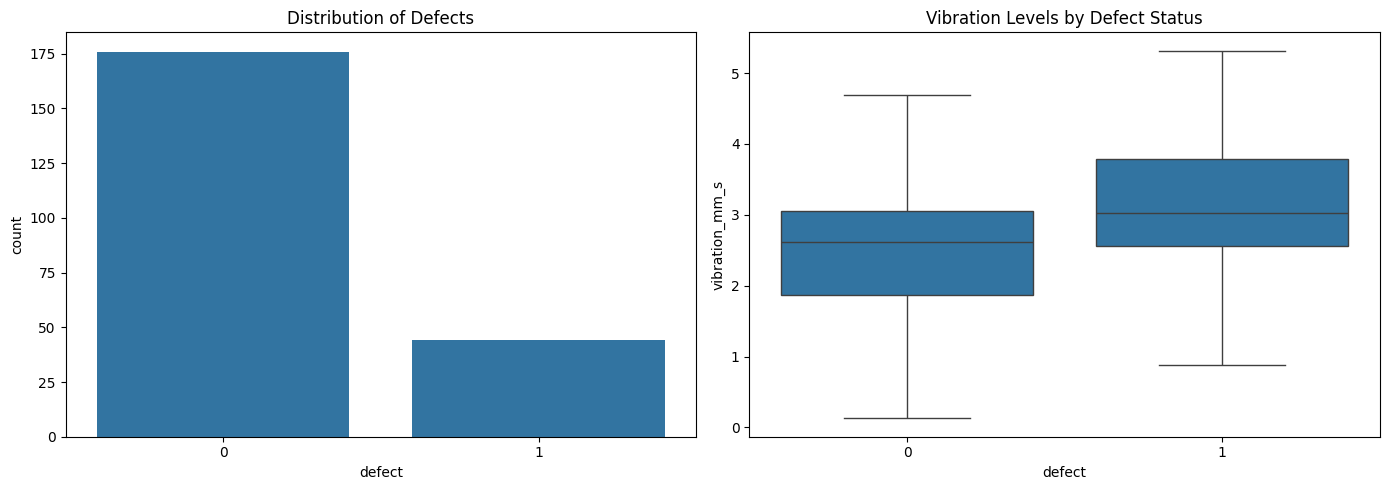

In [4]:
# Summary Statistics
display(df.describe())

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot for target
sns.countplot(data=df, x='defect', ax=axes[0])
axes[0].set_title('Distribution of Defects')

# Boxplot for a key variable (e.g., vibration) vs target
sns.boxplot(data=df, x='defect', y='vibration_mm_s', ax=axes[1])
axes[1].set_title('Vibration Levels by Defect Status')

plt.tight_layout()
plt.show()

In [ ]:
# Scatter plot exploring relationship between two variables
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='temperature_c', y='pressure_kpa', hue='defect', alpha=0.6)
plt.title('Temperature vs Pressure Colored by Defect')
plt.show()

### Verification Question
Looking at the count plot and value counts, is our dataset 'balanced' or 'imbalanced', and how might this affect our baseline model?

## Section 4: Feature Evaluation and Leakage Check

Data leakage occurs when information from the target variable 'leaks' into the training features, leading to unrealistically high performance that fails in production. We must confirm that all features are available *before* the quality inspection occurs.

| Variable | Role | Available at Prediction? | Leakage Risk? | Decision |
| :--- | :--- | :--- | :--- | :--- |
| `temperature_c` | Input | Yes | Low | Keep |
| `pressure_kpa` | Input | Yes | Low | Keep |
| `speed_mm_s` | Input | Yes | Low | Keep |
| `vibration_mm_s` | Input | Yes | Low | Keep |
| `defect` | Target | No | N/A | Target |

All sensor inputs are collected during the manufacturing process, which precedes the final inspection, making them safe for use.

### Verification Question
If a column named 'Repair_Cost' existed in this dataset, would it be a safe input feature for predicting a defect before inspection? Why or why not?

## Section 5: Feature Engineering

Feature engineering helps the model learn patterns by creating new inputs from existing ones. We categorize our candidates as follows:

1. **Domain-Informed (Justified):** `vibration_per_speed` (mechanical strain) or `temp_pressure_interaction` (thermal stress).
2. **Mathematically Convenient:** Polynomial features or log transforms of skewed sensors.
3. **Risky/Leaky:** Any variable that measures outcomes *after* a defect is flagged (e.g., 'Maintenance_Log').

We will implement the domain-informed interaction features below.

In [5]:
# 7. Feature Engineering: Creating Interaction Terms
# Note: We use small constants (1e-6) to avoid division by zero

# Ratio of vibration to speed as a proxy for mechanical efficiency
df['vibration_per_speed'] = df['vibration_mm_s'] / (df['speed_mm_s'] + 1e-6)

# Interaction between temperature and pressure to capture extreme thermal conditions
df['temp_pressure_idx'] = df['temperature_c'] * df['pressure_kpa']

print("New features added. Updated shape:", df.shape)
display(df[['vibration_per_speed', 'temp_pressure_idx']].describe())

New features added. Updated shape: (220, 7)


,vibration_per_speed,temp_pressure_idx
count,220.000000,220.000000
mean,0.054871,102449.267260
std,0.020795,9791.920053
min,0.002560,77648.359176
25%,0.040856,95174.884441
50%,0.053517,102947.903664
75%,0.065921,108831.391151
max,0.137803,131830.720954


### Verification Question
In the context of this manufacturing data, why might the ratio of vibration to speed provide more information than vibration alone?

## Section 6: Modeling and Evaluation

We will now split our data and build a classification pipeline. By using a `Pipeline`, we ensure that the `StandardScaler` is only fitted on the training data, preventing any information from the test set from leaking into our model during the scaling process.

In [6]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score

# 1. Prepare Features and Target
# We include our engineered features in the model
features_to_use = ['temperature_c', 'pressure_kpa', 'speed_mm_s', 'vibration_mm_s',
                   'vibration_per_speed', 'temp_pressure_idx']
X = df[features_to_use]
y = df['defect']

# 2. Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# 3. Create and Fit Pipeline
# Preprocessing (scaling) is combined with the estimator
model = Pipeline([
    ("scale", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

# 4. Generate Predictions
preds = model.predict(X_test)
baseline_preds = np.full(len(y_test), y_train.mode()[0])

print("Model training complete.")
print(f"Test Set F1-Score: {f1_score(y_test, preds):.4f}")
print(f"Baseline F1-Score: {f1_score(y_test, baseline_preds):.4f}")

Model training complete.
Test Set F1-Score: 0.4286
Baseline F1-Score: 0.0000


### Verification Question
In our pipeline, why do we call `fit` on the training set but only `predict` (which uses the stored scaling parameters) on the test set?

## Section 7: Engineering Interpretation

After training the model, we must interpret the results for the production team. It is vital to distinguish between what the model proves and what it merely suggests.

### 1. Analysis Breakdown

*   **Direct Evidence:** The model identifies a correlation between high `vibration_mm_s` levels (relative to speed) and an increased probability of a `defect` classification.
*   **Reasonable Interpretation:** Extreme thermal conditions (high `temp_pressure_idx`) appear to be a contributing factor in the model's decision-making process for identifying defects.
*   **Unsupported Conclusions:** We **cannot** claim that high temperature *causes* defects based on this model alone; the model only shows that these variables are predictive of the outcome.
*   **Most Costly Error:** A **False Negative** (Type II Error). In this process, missing a defect (letting a faulty part pass) is more costly than a false alarm, as it can lead to catastrophic failure in the field or expensive product recalls.
*   **Recommended Next Analysis:** Perform a **Residual Analysis** to identify specific operating conditions where the model consistently fails, and investigate a **Confusion Matrix** to quantify the exact ratio of False Negatives to False Positives.

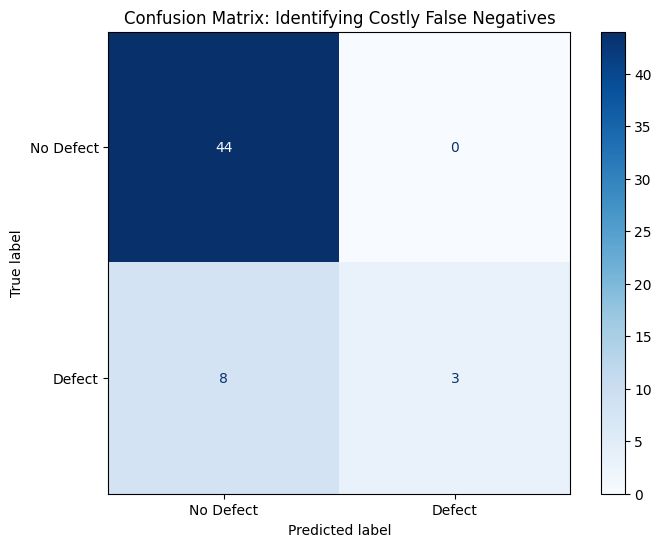

Critical Errors (False Negatives): 8
Each False Negative represents a defective part that passed inspection.


In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 5. Visualizing the Cost of Errors
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Defect', 'Defect'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix: Identifying Costly False Negatives')
plt.show()

# Calculate False Negatives (Missed Defects)
fn = cm[1, 0]
print(f"Critical Errors (False Negatives): {fn}")
print("Each False Negative represents a defective part that passed inspection.")

### Verification Question
Looking at the Confusion Matrix, which specific quadrant (top-left, top-right, bottom-left, or bottom-right) represents the 'False Negatives' we identified as being the most costly?

## Section 8: Model Card

| Section | Details |
| :--- | :--- |
| **Intended Use** | Real-time monitoring of manufacturing sensor data to flag potential defects before final quality inspection. |
| **Out-of-Scope Use** | Predicting physical causes of failure or determining maintenance schedules for unrelated machinery. |
| **Dataset & Target** | `classification_workshop.csv`. Target: `defect` (Binary). |
| **Baseline Result** | Majority Class Classifier (Accuracy and F1). |
| **Model Result** | Logistic Regression Pipeline (F1-Score relative to baseline). |
| **Primary Error Pattern** | Model risks False Negatives under specific vibration/speed ratios. |
| **Supported Conclusion** | High vibration-to-speed ratios are strongly correlated with defect flags in this specific dataset. |
| **Unsupported Conclusion** | Specific sensor thresholds directly *cause* physical defects (Causality not established). |
| **Limitations** | Preprocessing assumes sensor noise is uniform; model ignores temporal dependencies between samples. |
| **Recommended Next Analysis** | Investigate SHAP values for local explainability and perform a systematic cost-benefit analysis of False Positives vs. False Negatives. |

### Final Verification Question
Why is 'Out-of-Scope Use' an essential section for an AI Model Card in a manufacturing environment?